#ePGD Computer Vision: Term Project


# Classifier-Free and Classifier-Guided Diffusion models

This notebook implements two diffusion model guidance strategies on the CIFAR-10 dataset:

1. **Classifier-Free Guidance** (Ho & Salimans, 2022): A single model trained with random label dropout, enabling guidance without a separate classifier.
2. **Classifier-Guided Guidance** (Dhariwal & Nichol, 2021): Uses a separately trained noisy-image classifier to steer the diffusion sampling process.

Both approaches build on DDPM (Ho et al., 2020) as the base diffusion framework.

---


## 1. Setup & Installation

In [ ]:
!pip install -q torch torchvision matplotlib tqdm einops

In [ ]:
#imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
import math
import os
from einops import rearrange

#checking device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA A100-SXM4-80GB


## 2. Configuration

In [ ]:
##Defining configurations
class Config:
    image_size = 32 #CIFAR 10 images are 32*32 pixels
    channels = 3 # RGB channels
    num_classes = 10

    # Diffusion
    timesteps = 1000 #timesteps to add/remove noise
    beta_start = 1e-4 #noise schedule
    beta_end = 0.02

    # U-Net architecture
    base_channels = 128
    channel_mults = (1, 2, 2, 2) #channel increase through U Net across stages
    num_res_blocks = 2
    attention_resolutions = (16,)  # applying self attention at 16x16 feature map
    dropout = 0.1
    time_emb_dim = 512

    # Training
    batch_size = 128
    learning_rate = 2e-4
    diffusion_epochs = 60
    classifier_epochs = 30
    ema_decay = 0.9999  # exponential moving average to maintain smoothed weights

    # Classifier-free guidance
    p_uncond = 0.1                 # probability of dropping class label
    cfg_scale = 3.0                # guidance scale w for classifier-free

    # Classifier guidance
    cg_scale = 1.0                 # guidance scale for classifier-guided

    # CIFAR-10 class names
    class_names = [
        'airplane', 'automobile', 'bird', 'cat', 'deer',
        'dog', 'frog', 'horse', 'ship', 'truck'
    ]

cfg = Config() #instance og config class

## 3. Diffusion Schedule Utilities

We use a **linear beta schedule** and pre-compute all required quantities for the forward (noising) and reverse (denoising) processes.

In [ ]:
class DiffusionSchedule:
    """Pre-computes and stores all diffusion schedule quantities."""

    def __init__(self, timesteps=1000, beta_start=1e-4, beta_end=0.02, device='cuda'):
        self.timesteps = timesteps
        self.device = device

        betas = torch.linspace(beta_start, beta_end, timesteps, device=device)
        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

        self.betas = betas
        self.alphas = alphas
        self.alphas_cumprod = alphas_cumprod
        self.alphas_cumprod_prev = alphas_cumprod_prev
        self.sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
        self.sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

        # Posterior q(x_{t-1} | x_t, x_0)
        self.posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
        self.posterior_log_variance_clipped = torch.log(
            torch.clamp(self.posterior_variance, min=1e-20)
        )
        self.posterior_mean_coef1 = betas * torch.sqrt(alphas_cumprod_prev) / (1.0 - alphas_cumprod)
        self.posterior_mean_coef2 = (1.0 - alphas_cumprod_prev) * torch.sqrt(alphas) / (1.0 - alphas_cumprod)

    def _extract(self, a, t, x_shape):
        """Extract values from schedule tensor at timestep t, shaped for broadcasting."""
        batch_size = t.shape[0]
        out = a.gather(-1, t)
        return out.reshape(batch_size, *((1,) * (len(x_shape) - 1)))

    def q_sample(self, x_start, t, noise=None):
        """Forward diffusion: q(x_t | x_0) = sqrt(alpha_bar_t) * x_0 + sqrt(1-alpha_bar_t) * eps"""
        if noise is None:
            noise = torch.randn_like(x_start)
        sqrt_ab = self._extract(self.sqrt_alphas_cumprod, t, x_start.shape)
        sqrt_one_minus_ab = self._extract(self.sqrt_one_minus_alphas_cumprod, t, x_start.shape)
        return sqrt_ab * x_start + sqrt_one_minus_ab * noise, noise

    def predict_x0_from_noise(self, x_t, t, noise):
        sqrt_ab = self._extract(self.sqrt_alphas_cumprod, t, x_t.shape)
        sqrt_one_minus_ab = self._extract(self.sqrt_one_minus_alphas_cumprod, t, x_t.shape)
        return (x_t - sqrt_one_minus_ab * noise) / sqrt_ab

    def q_posterior_mean_variance(self, x_start, x_t, t):
        posterior_mean = (
            self._extract(self.posterior_mean_coef1, t, x_t.shape) * x_start
            + self._extract(self.posterior_mean_coef2, t, x_t.shape) * x_t
        )
        posterior_variance = self._extract(self.posterior_variance, t, x_t.shape)
        posterior_log_variance = self._extract(self.posterior_log_variance_clipped, t, x_t.shape)
        return posterior_mean, posterior_variance, posterior_log_variance


schedule = DiffusionSchedule(
    timesteps=cfg.timesteps,
    beta_start=cfg.beta_start,
    beta_end=cfg.beta_end,
    device=device
)
print(f"Diffusion schedule ready: {cfg.timesteps} timesteps")

Diffusion schedule ready: 1000 timesteps


## 4. U-Net Architecture

The denoising network is a U-Net conditioned on:
- **Timestep** via sinusoidal embeddings
- **Class label** via learned embeddings (added to the time embedding)

For classifier-free guidance, we use a special "null" class index (`num_classes`) to represent the unconditional case.

The architecture follows the guided-diffusion pattern: each input/output block is either a `ResAttnBlock` (ResBlock + optional Attention) or a spatial resampler, and each produces/consumes exactly **one** skip connection.

In [ ]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.GroupNorm(32, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_ch),
        )
        self.norm2 = nn.GroupNorm(32, out_ch)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.conv2(self.dropout(F.silu(self.norm2(h))))
        return h + self.shortcut(x)


class AttentionBlock(nn.Module):
    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.norm = nn.GroupNorm(32, channels)
        self.attn = nn.MultiheadAttention(channels, num_heads, batch_first=True)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)
        h = rearrange(h, 'b c h w -> b (h w) c')
        h, _ = self.attn(h, h, h)
        h = rearrange(h, 'b (h w) c -> b c h w', h=H, w=W)
        return x + h


class ResAttnBlock(nn.Module):
    """ResBlock + optional Attention, treated as one unit for skip connections."""

    def __init__(self, in_ch, out_ch, time_emb_dim, dropout=0.1, use_attn=False):
        super().__init__()
        self.res = ResBlock(in_ch, out_ch, time_emb_dim, dropout)
        self.attn = AttentionBlock(out_ch) if use_attn else nn.Identity()

    def forward(self, x, t_emb):
        x = self.res(x, t_emb)
        x = self.attn(x)
        return x


class DownsampleBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 3, stride=2, padding=1)

    def forward(self, x, t_emb=None):
        return self.conv(x)


class UpsampleBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='nearest')
        self.conv = nn.Conv2d(channels, channels, 3, padding=1)

    def forward(self, x, t_emb=None):
        return self.conv(self.up(x))

In [ ]:
class UNet(nn.Module):
    """
    U-Net noise prediction model with time + class conditioning.
    Supports classifier-free guidance via a null class token.

    Each input_block is either a ResAttnBlock or a DownsampleBlock, and each
    produces exactly one skip connection entry. The output_blocks mirror
    them in reverse, consuming one skip each via ResAttnBlock.
    """

    def __init__(self, cfg):
        super().__init__()
        C = cfg.base_channels
        ch_mults = cfg.channel_mults
        t_dim = cfg.time_emb_dim

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(C),
            nn.Linear(C, t_dim),
            nn.SiLU(),
            nn.Linear(t_dim, t_dim),
        )
        self.class_emb = nn.Embedding(cfg.num_classes + 1, t_dim)
        self.init_conv = nn.Conv2d(cfg.channels, C, 3, padding=1)

        # ---- Down path ----
        self.input_blocks = nn.ModuleList()
        input_block_chans = [C]
        now_ch = C
        ds = cfg.image_size

        for level, mult in enumerate(ch_mults):
            out_ch = C * mult
            for _ in range(cfg.num_res_blocks):
                use_attn = (ds in cfg.attention_resolutions)
                self.input_blocks.append(
                    ResAttnBlock(now_ch, out_ch, t_dim, cfg.dropout, use_attn)
                )
                now_ch = out_ch
                input_block_chans.append(now_ch)
            if level < len(ch_mults) - 1:
                self.input_blocks.append(DownsampleBlock(now_ch))
                input_block_chans.append(now_ch)
                ds //= 2

        # ---- Bottleneck ----
        self.mid = nn.ModuleList([
            ResBlock(now_ch, now_ch, t_dim, cfg.dropout),
            AttentionBlock(now_ch),
            ResBlock(now_ch, now_ch, t_dim, cfg.dropout),
        ])

        # ---- Up path ----
        self.output_blocks = nn.ModuleList()

        for level, mult in enumerate(reversed(ch_mults)):
            out_ch = C * mult
            for i in range(cfg.num_res_blocks + 1):
                skip_ch = input_block_chans.pop()
                use_attn = (ds in cfg.attention_resolutions)
                self.output_blocks.append(
                    ResAttnBlock(now_ch + skip_ch, out_ch, t_dim, cfg.dropout, use_attn)
                )
                now_ch = out_ch
                if level < len(ch_mults) - 1 and i == cfg.num_res_blocks:
                    self.output_blocks.append(UpsampleBlock(now_ch))
                    ds *= 2

        self.final_norm = nn.GroupNorm(32, now_ch)
        self.final_conv = nn.Conv2d(now_ch, cfg.channels, 1)

    def forward(self, x, t, y):
        """
        Args:
            x: (B, C, H, W) noisy image
            t: (B,) integer timesteps
            y: (B,) class labels (use num_classes for unconditional)
        Returns:
            predicted noise (B, C, H, W)
        """
        t_emb = self.time_mlp(t) + self.class_emb(y)

        h = self.init_conv(x)
        skips = [h]

        for block in self.input_blocks:
            h = block(h, t_emb)
            skips.append(h)

        for layer in self.mid:
            h = layer(h, t_emb) if isinstance(layer, ResBlock) else layer(h)

        for block in self.output_blocks:
            if isinstance(block, ResAttnBlock):
                h = torch.cat([h, skips.pop()], dim=1)
            h = block(h, t_emb)

        h = self.final_conv(F.silu(self.final_norm(h)))
        return h


model = UNet(cfg).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"U-Net parameters: {total_params / 1e6:.2f}M")

U-Net parameters: 35.75M


## 5. Classifier for Classifier-Guided Diffusion

A ResNet-style classifier trained on **noisy images** at various timesteps. This is the key distinction from a standard image classifier, it must handle noisy inputs to provide useful gradients during the reverse diffusion process.


In [ ]:
class NoisyClassifier(nn.Module):
    """Classifier trained on noisy images p(y | x_t, t)."""

    def __init__(self, cfg):
        super().__init__()
        C = 64 #channels
        t_dim = 256

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(C),
            nn.Linear(C, t_dim),
            nn.SiLU(),
            nn.Linear(t_dim, t_dim),
        )

        self.net = nn.Sequential(
            # 32 -> 16
            nn.Conv2d(cfg.channels, C, 3, padding=1),
            nn.GroupNorm(8, C),
            nn.SiLU(),
            nn.Conv2d(C, C, 3, stride=2, padding=1),
            nn.GroupNorm(8, C),
            nn.SiLU(),
            # 16 -> 8
            nn.Conv2d(C, C * 2, 3, padding=1),
            nn.GroupNorm(8, C * 2),
            nn.SiLU(),
            nn.Conv2d(C * 2, C * 2, 3, stride=2, padding=1),
            nn.GroupNorm(8, C * 2),
            nn.SiLU(),
            # 8 -> 4
            nn.Conv2d(C * 2, C * 4, 3, padding=1),
            nn.GroupNorm(8, C * 4),
            nn.SiLU(),
            nn.Conv2d(C * 4, C * 4, 3, stride=2, padding=1),
            nn.GroupNorm(8, C * 4),
            nn.SiLU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
        )

        self.head = nn.Sequential(
            nn.Linear(C * 4 + t_dim, 256),
            nn.SiLU(),
            nn.Dropout(0.1),
            nn.Linear(256, cfg.num_classes),
        )

    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        feat = self.net(x)
        return self.head(torch.cat([feat, t_emb], dim=1))


classifier = NoisyClassifier(cfg).to(device)
cls_params = sum(p.numel() for p in classifier.parameters())
print(f"Classifier parameters: {cls_params / 1e6:.2f}M")

Classifier parameters: 1.36M


## 6. Dataset

100%|██████████| 170M/170M [00:06<00:00, 28.0MB/s]


Training samples: 50000
Batches per epoch: 390


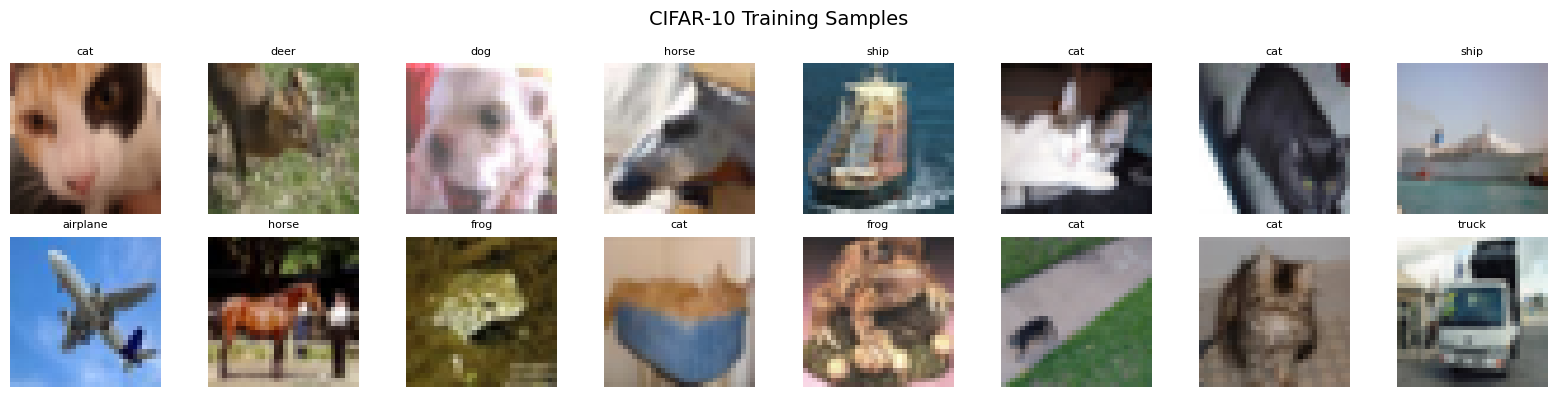

In [ ]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),  # [-1, 1]
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)
train_loader = DataLoader(
    train_dataset, batch_size=cfg.batch_size, shuffle=True,
    num_workers=2, pin_memory=True, drop_last=True
)

print(f"Training samples: {len(train_dataset)}")
print(f"Batches per epoch: {len(train_loader)}")

# Visualize some training images
sample_images, sample_labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    img = sample_images[i].permute(1, 2, 0).numpy() * 0.5 + 0.5
    ax.imshow(img)
    ax.set_title(cfg.class_names[sample_labels[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('CIFAR-10 Training Samples', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Visualizing the Forward Diffusion Process

Demonstrating how an image progressively becomes noise.

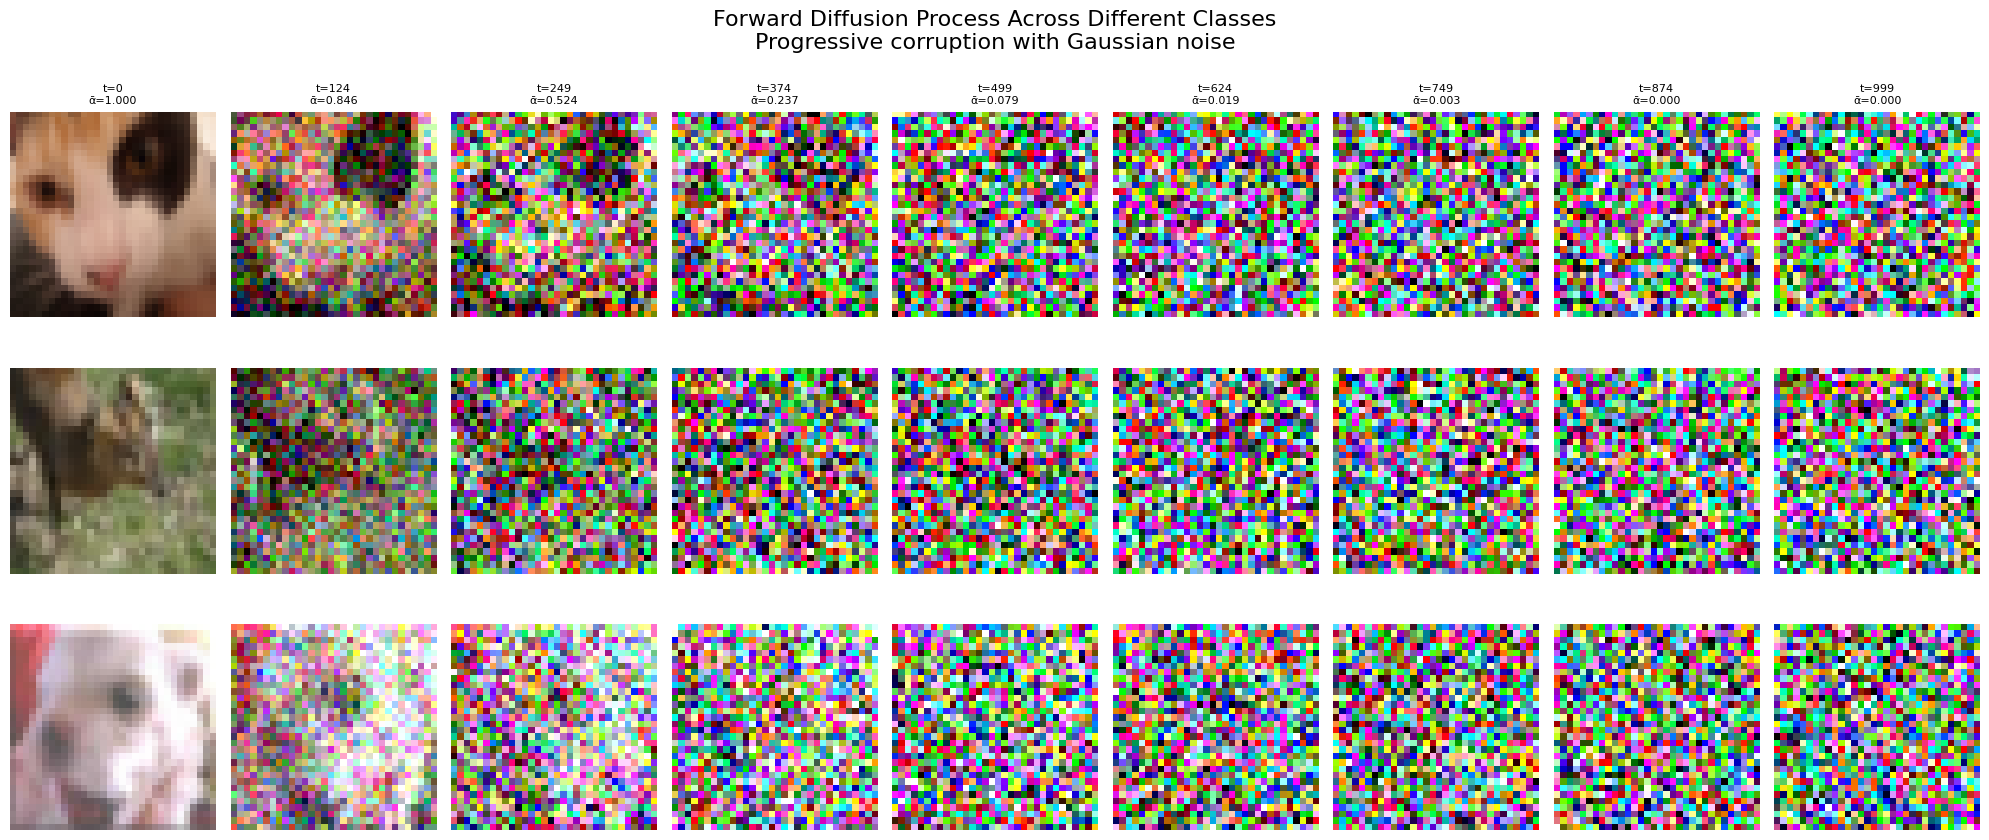

In [ ]:
def show_forward_processes(
    schedule,
    images,
    labels,
    num_images=3,
    num_steps=8,
    save_path=None
):
    """
    Show forward diffusion for multiple images/classes.
    Great for PPT visualization.
    """

    timesteps = torch.linspace(
        0,
        cfg.timesteps - 1,
        num_steps + 1
    ).long()

    fig, axes = plt.subplots(
        num_images,
        num_steps + 1,
        figsize=(20, 3 * num_images)
    )

    # Handle single-row edge case
    if num_images == 1:
        axes = axes[None, :]

    for row in range(num_images):

        x0 = images[row:row+1].to(device)
        class_name = cfg.class_names[labels[row]]

        for col, t in enumerate(timesteps):

            t_tensor = torch.tensor([t], device=device)

            # Generate noisy image
            if t == 0:
                x_noisy = x0
            else:
                x_noisy, _ = schedule.q_sample(x0, t_tensor)

            # Convert image for plotting
            img = x_noisy[0].detach().cpu()
            img = img.permute(1, 2, 0).numpy()

            # Denormalize [-1,1] → [0,1]
            img = (img + 1) / 2
            img = np.clip(img, 0, 1)

            axes[row, col].imshow(img)
            axes[row, col].axis('off')

            # Top row titles
            if row == 0:
                alpha_bar = schedule.alphas_cumprod[t].item()

                axes[row, col].set_title(
                    f"t={t.item()}\nᾱ={alpha_bar:.3f}",
                    fontsize=8
                )

        # Row labels (class names)
        axes[row, 0].set_ylabel(
            class_name,
            fontsize=12,
            rotation=90,
            labelpad=15
        )

    plt.suptitle(
        "Forward Diffusion Process Across Different Classes\n"
        "Progressive corruption with Gaussian noise",
        fontsize=16
    )

    plt.tight_layout()

    # Save for PPT
    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches='tight'
        )

    plt.show()

#function call
show_forward_processes(
    schedule,
    sample_images,
    sample_labels,
    num_images=3,
    num_steps=8,
    save_path="multi_forward_diffusion.png"
)

## 8. EMA (Exponential Moving Average)

Maintains a smoothed copy of model weights for better sample quality.

In [ ]:
class EMA:
    def __init__(self, model, decay=0.9999):
        self.model = model
        self.decay = decay
        self.shadow = {}
        self.backup = {}
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.data.clone()

    def update(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                self.shadow[name].mul_(self.decay).add_(param.data, alpha=1 - self.decay)

    def apply_shadow(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                self.backup[name] = param.data.clone()
                param.data.copy_(self.shadow[name])

    def restore(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                param.data.copy_(self.backup[name])
        self.backup = {}

## 9. Train the Diffusion Model (U-Net)

Training with **random label dropout** (`p_uncond = 0.1`) so the same model supports both conditional and unconditional generation. This is the key element for classifier-free guidance.

**Loss:** Simple MSE between predicted noise and actual noise (epsilon-prediction).

In [ ]:
def train_diffusion(model, schedule, train_loader, cfg, device):
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.learning_rate, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.diffusion_epochs)
    ema = EMA(model, decay=cfg.ema_decay)

    model.train()
    losses = []

    for epoch in range(cfg.diffusion_epochs):
        epoch_loss = 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{cfg.diffusion_epochs}")

        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            B = images.shape[0]

            # Random label dropout for classifier-free guidance
            drop_mask = torch.rand(B, device=device) < cfg.p_uncond
            labels = torch.where(drop_mask, torch.full_like(labels, cfg.num_classes), labels)

            t = torch.randint(0, cfg.timesteps, (B,), device=device)
            noise = torch.randn_like(images)
            x_noisy, _ = schedule.q_sample(images, t, noise)

            predicted_noise = model(x_noisy, t, labels)
            loss = F.mse_loss(predicted_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            ema.update()

            epoch_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        scheduler.step()
        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}: avg_loss={avg_loss:.4f}, lr={scheduler.get_last_lr()[0]:.6f}")

    return ema, losses


print("Training diffusion model...")
print(f"Config: {cfg.diffusion_epochs} epochs, batch_size={cfg.batch_size}, lr={cfg.learning_rate}")
print(f"Classifier-free label dropout probability: {cfg.p_uncond}")
ema, diff_losses = train_diffusion(model, schedule, train_loader, cfg, device)

Training diffusion model...
Config: 60 epochs, batch_size=128, lr=0.0002
Classifier-free label dropout probability: 0.1


Epoch 1/60:   0%|          | 0/390 [00:00<?, ?it/s]

Epoch 2/60:   0%|          | 0/390 [00:00<?, ?it/s]

Epoch 3/60:   0%|          | 0/390 [00:00<?, ?it/s]

Epoch 4/60:   0%|          | 0/390 [00:00<?, ?it/s]

...

Epoch 57/60:   0%|          | 0/390 [00:00<?, ?it/s]

Epoch 58/60:   0%|          | 0/390 [00:00<?, ?it/s]

Epoch 59/60:   0%|          | 0/390 [00:00<?, ?it/s]

Epoch 60/60:   0%|          | 0/390 [00:00<?, ?it/s]

  Epoch 60: avg_loss=0.0294, lr=0.000000


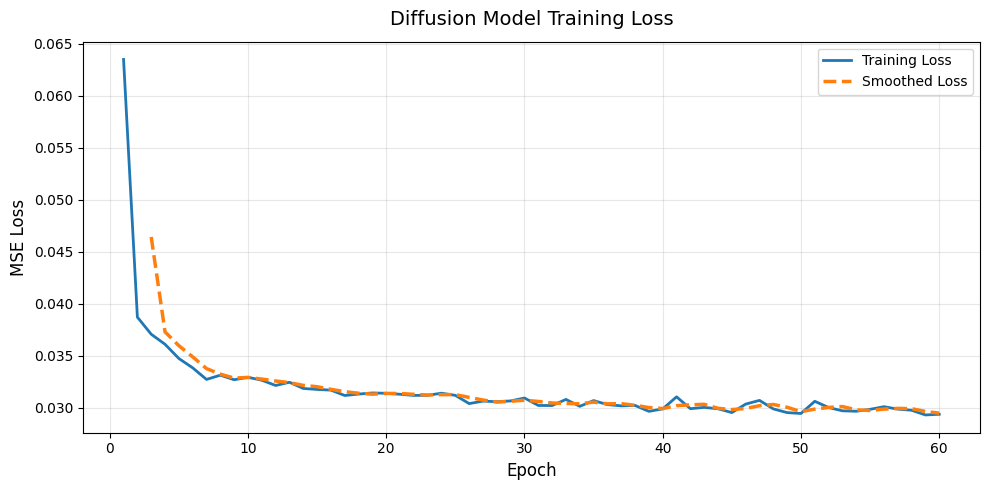

In [ ]:
#Visualizing training loss
plt.figure(figsize=(10, 5))

epochs = range(1, len(diff_losses) + 1)

plt.plot(
    epochs,
    diff_losses,
    linewidth=2,
    label='Training Loss'
)

# Optional smoothing
window = 3
if len(diff_losses) >= window:
    smooth_losses = np.convolve(
        diff_losses,
        np.ones(window)/window,
        mode='valid'
    )

    plt.plot(
        range(window, len(diff_losses)+1),
        smooth_losses,
        linewidth=2.5,
        linestyle='--',
        label='Smoothed Loss'
    )

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)

plt.title(
    'Diffusion Model Training Loss',
    fontsize=14,
    pad=12
)

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

# Save high-quality image for PPT
plt.savefig(
    "diffusion_training_loss.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## 10. Training the Noisy-Image Classifier

For classifier-guided diffusion, we need a classifier $p_\phi(y \mid x_t, t)$ that can classify images at any noise level. We train it by sampling random timesteps and adding the corresponding noise to clean images.

In [ ]:
def train_classifier(classifier, schedule, train_loader, cfg, device):
    optimizer = torch.optim.AdamW(classifier.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.classifier_epochs)

    classifier.train()
    losses = []
    accuracies = []

    for epoch in range(cfg.classifier_epochs):
        epoch_loss = 0.0
        correct = 0
        total = 0
        pbar = tqdm(train_loader, desc=f"Classifier Epoch {epoch+1}/{cfg.classifier_epochs}")

        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            B = images.shape[0]

            t = torch.randint(0, cfg.timesteps, (B,), device=device)
            x_noisy, _ = schedule.q_sample(images, t)

            logits = classifier(x_noisy, t)
            loss = F.cross_entropy(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(classifier.parameters(), 1.0)
            optimizer.step()

            epoch_loss += loss.item()
            correct += (logits.argmax(1) == labels).sum().item()
            total += B
            pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{100*correct/total:.1f}%")

        scheduler.step()
        avg_loss = epoch_loss / len(train_loader)
        acc = 100 * correct / total
        losses.append(avg_loss)
        accuracies.append(acc)
        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}: loss={avg_loss:.4f}, accuracy={acc:.1f}%")

    return losses, accuracies


print("Training noisy-image classifier for classifier-guided diffusion...")
cls_losses, cls_accs = train_classifier(classifier, schedule, train_loader, cfg, device)

Training noisy-image classifier for classifier-guided diffusion...


Classifier Epoch 1/30:   0%|          | 0/390 [00:00<?, ?it/s]

Classifier Epoch 2/30:   0%|          | 0/390 [00:00<?, ?it/s]

Classifier Epoch 3/30:   0%|          | 0/390 [00:00<?, ?it/s]

Classifier Epoch 4/30:   0%|          | 0/390 [00:00<?, ?it/s]

...

Classifier Epoch 28/30:   0%|          | 0/390 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79783017cae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
         ^  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79783017cae0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Classifier Epoch 29/30:   0%|          | 0/390 [00:00<?, ?it/s]

Classifier Epoch 30/30:   0%|          | 0/390 [00:00<?, ?it/s]

  Epoch 30: loss=1.7069, accuracy=36.8%


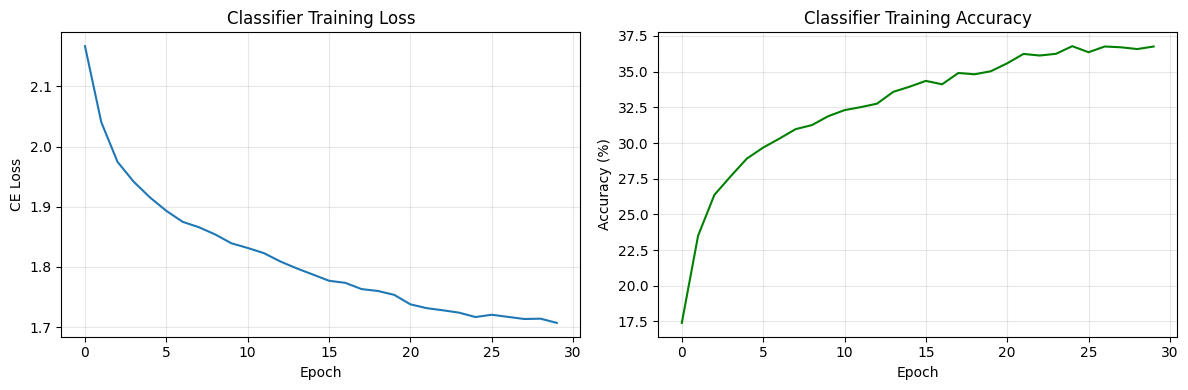

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(cls_losses, linewidth=1.5)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('CE Loss')
ax1.set_title('Classifier Training Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(cls_accs, linewidth=1.5, color='green')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Classifier Training Accuracy')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Sampling Functions

We implement three sampling strategies:

1. **Conditional DDPM** — standard reverse diffusion
2. **Classifier-Free Guidance** — interpolates between conditional and unconditional predictions
3. **Classifier-Guided** — uses gradients from the noisy classifier to steer generation

In [ ]:
@torch.no_grad()
def sample_ddpm(model, schedule, n_samples, labels, cfg, device):
    """Standard conditional DDPM sampling (no guidance)."""
    model.eval()
    x = torch.randn(n_samples, cfg.channels, cfg.image_size, cfg.image_size, device=device)

    for t in tqdm(reversed(range(cfg.timesteps)), total=cfg.timesteps, desc="DDPM"):
        t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)
        predicted_noise = model(x, t_batch, labels)

        alpha = schedule.alphas[t]
        alpha_bar = schedule.alphas_cumprod[t]
        beta = schedule.betas[t]

        mean = (1 / torch.sqrt(alpha)) * (
            x - (beta / torch.sqrt(1 - alpha_bar)) * predicted_noise
        )

        if t > 0:
            noise = torch.randn_like(x)
            sigma = torch.sqrt(beta)
            x = mean + sigma * noise
        else:
            x = mean

    model.train()
    return x.clamp(-1, 1)


@torch.no_grad()
def sample_classifier_free(model, schedule, n_samples, labels, cfg, device, w=None):
    """
    Classifier-Free Guidance sampling.
    eps_guided = (1 + w) * eps_cond - w * eps_uncond
    """
    if w is None:
        w = cfg.cfg_scale
    model.eval()
    x = torch.randn(n_samples, cfg.channels, cfg.image_size, cfg.image_size, device=device)
    null_labels = torch.full_like(labels, cfg.num_classes)  # unconditional token

    for t in tqdm(reversed(range(cfg.timesteps)), total=cfg.timesteps, desc=f"CFG (w={w})"):
        t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)

        eps_cond = model(x, t_batch, labels)
        eps_uncond = model(x, t_batch, null_labels)
        predicted_noise = (1 + w) * eps_cond - w * eps_uncond

        alpha = schedule.alphas[t]
        alpha_bar = schedule.alphas_cumprod[t]
        beta = schedule.betas[t]

        mean = (1 / torch.sqrt(alpha)) * (
            x - (beta / torch.sqrt(1 - alpha_bar)) * predicted_noise
        )

        if t > 0:
            noise = torch.randn_like(x)
            sigma = torch.sqrt(beta)
            x = mean + sigma * noise
        else:
            x = mean

    model.train()
    return x.clamp(-1, 1)


def sample_classifier_guided(model, classifier, schedule, n_samples, labels, cfg, device, s=None):
    """
    Classifier-Guided Diffusion sampling.
    eps_guided = eps - sqrt(1 - alpha_bar) * s * grad_x log p(y | x_t, t)
    """
    if s is None:
        s = cfg.cg_scale
    model.eval()
    classifier.eval()
    x = torch.randn(n_samples, cfg.channels, cfg.image_size, cfg.image_size, device=device)

    for t in tqdm(reversed(range(cfg.timesteps)), total=cfg.timesteps, desc=f"CG (s={s})"):
        t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)

        # Get classifier gradient
        x_in = x.detach().requires_grad_(True)
        logits = classifier(x_in, t_batch)
        log_probs = F.log_softmax(logits, dim=-1)
        selected = log_probs[torch.arange(n_samples, device=device), labels]
        grad = torch.autograd.grad(selected.sum(), x_in)[0]

        with torch.no_grad():
            # Use conditional labels for the diffusion model
            predicted_noise = model(x, t_batch, labels)

            alpha = schedule.alphas[t]
            alpha_bar = schedule.alphas_cumprod[t]
            beta = schedule.betas[t]

            # Modify noise prediction with classifier gradient
            guided_noise = predicted_noise - torch.sqrt(1 - alpha_bar) * s * grad

            mean = (1 / torch.sqrt(alpha)) * (
                x - (beta / torch.sqrt(1 - alpha_bar)) * guided_noise
            )

            if t > 0:
                noise = torch.randn_like(x)
                sigma = torch.sqrt(beta)
                x = mean + sigma * noise
            else:
                x = mean

    model.train()
    classifier.train()
    return x.clamp(-1, 1)

## 12. Generating Samples: Conditional DDPM

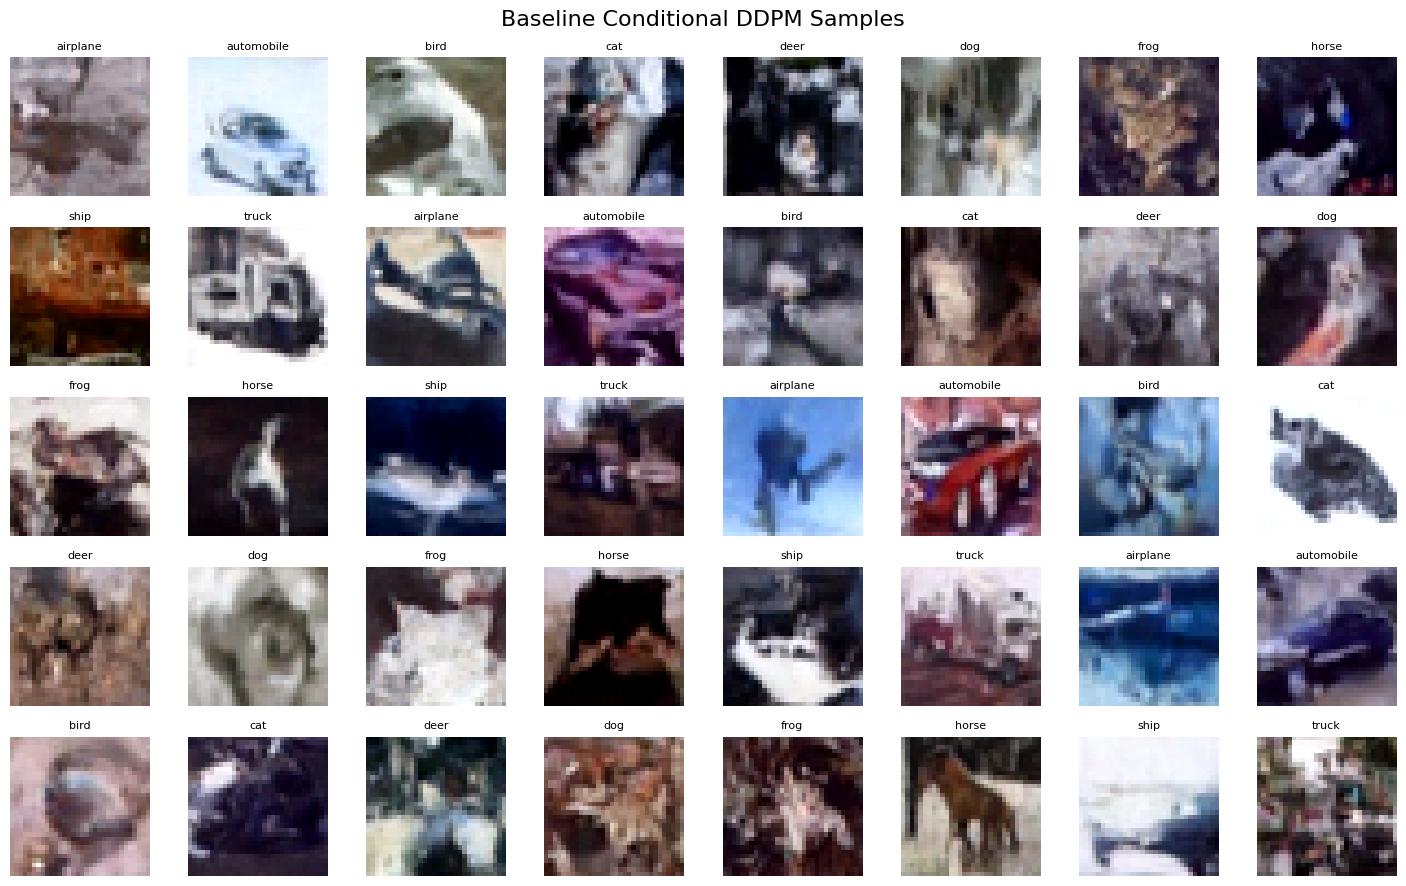

In [ ]:
def visualize_conditional_samples(
    images,
    title,
    class_names=None,
    labels=None,
    nrow=8,
    save_path=None
):

    images = (images * 0.5 + 0.5).clamp(0, 1)

    B = images.size(0)
    ncol = nrow
    nrows = math.ceil(B / ncol)

    fig, axes = plt.subplots(
        nrows,
        ncol,
        figsize=(ncol * 1.8, nrows * 1.8)
    )

    axes = np.array(axes).reshape(nrows, ncol)

    for idx in range(nrows * ncol):

        ax = axes[idx // ncol, idx % ncol]
        ax.axis('off')

        if idx < B:

            img = images[idx].permute(1,2,0).cpu().numpy()

            ax.imshow(img)

            # Show class labels
            if labels is not None and class_names is not None:
                ax.set_title(
                    class_names[labels[idx].item()],
                    fontsize=8
                )

    plt.suptitle(title, fontsize=16)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches='tight'
        )

    plt.show()

#function call
visualize_conditional_samples(
    samples_ddpm,
    'Baseline Conditional DDPM Samples',
    cfg.class_names,
    target_classes,
    nrow=8,
    save_path='baseline_conditional_ddpm.png'
)

## 13. Generating Samples: Classifier-Free Guidance

**Key idea:** The model was trained with random label dropout. At sampling time, we compute both conditional and unconditional noise predictions, then extrapolate away from the unconditional direction:

$$\tilde{\epsilon}_\theta(x_t, t, y) = (1 + w) \cdot \epsilon_\theta(x_t, t, y) - w \cdot \epsilon_\theta(x_t, t, \varnothing)$$

Higher $w$ → stronger guidance → sharper but less diverse images.

CFG (w=0.0):   0%|          | 0/1000 [00:00<?, ?it/s]

CFG (w=1.0):   0%|          | 0/1000 [00:00<?, ?it/s]

CFG (w=3.0):   0%|          | 0/1000 [00:00<?, ?it/s]

CFG (w=5.0):   0%|          | 0/1000 [00:00<?, ?it/s]

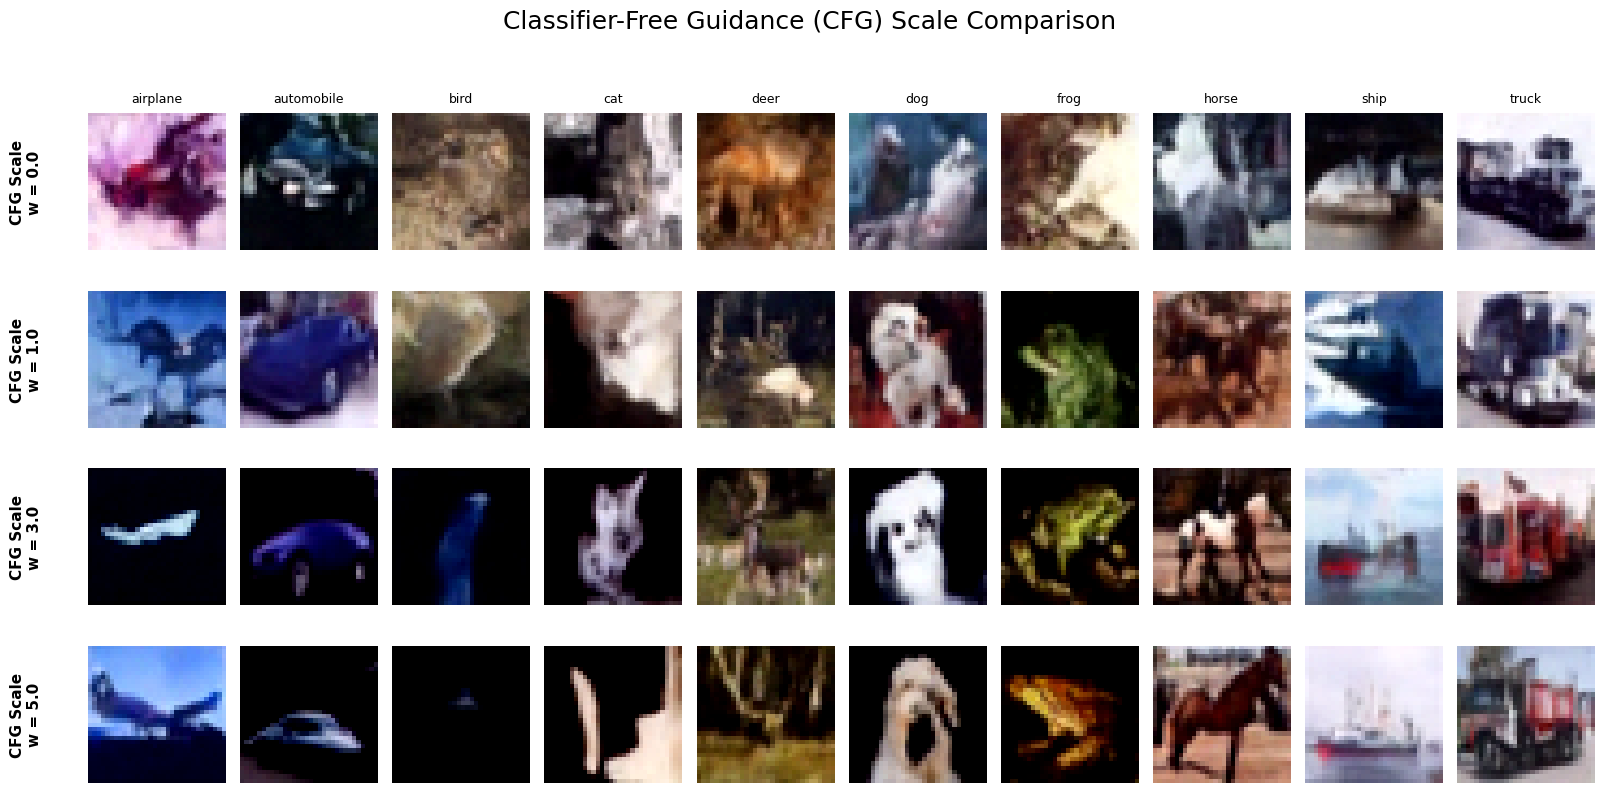

In [ ]:
def visualize_cfg_comparison(
    model,
    schedule,
    target_classes,
    cfg,
    device,
    guidance_scales=[0.0, 1.0, 3.0, 5.0],
    save_path=None
):

    ema.apply_shadow()

    rows = len(guidance_scales)
    cols = len(target_classes)

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(cols * 1.6, rows * 2.0)
    )

    # Handle edge case
    if rows == 1:
        axes = axes[None, :]

    for row, w in enumerate(guidance_scales):

        samples = sample_classifier_free(
            model,
            schedule,
            len(target_classes),
            target_classes,
            cfg,
            device,
            w=w
        )

        # Denormalize
        samples = (samples * 0.5 + 0.5).clamp(0, 1)

        for col in range(cols):

            img = samples[col].permute(1,2,0).cpu().numpy()

            axes[row, col].imshow(img)
            axes[row, col].axis('off')

            # Column titles (class names)
            if row == 0:
                axes[row, col].set_title(
                    cfg.class_names[target_classes[col]],
                    fontsize=9,
                    pad=8
                )

        # Add CFG scale label on left side
        axes[row, 0].text(
            -0.45,                 # move left
            0.5,
            f'CFG Scale\nw = {w}',
            transform=axes[row, 0].transAxes,
            fontsize=11,
            va='center',
            ha='center',
            rotation=90,
            fontweight='bold'
        )

    plt.suptitle(
        'Classifier-Free Guidance (CFG) Scale Comparison',
        fontsize=18,
        y=1.02
    )

    plt.tight_layout()

    # Save for PPT
    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches='tight'
        )

    plt.show()

    ema.restore()

#implementation

target_classes = torch.arange(10, device=device)

visualize_cfg_comparison(
    model,
    schedule,
    target_classes,
    cfg,
    device,
    guidance_scales=[0.0, 1.0, 3.0, 5.0],
    save_path='cfg_comparison.png'
)

## 14. Generating Samples: Classifier-Guided Diffusion

**Key idea:** We use gradients from the noisy-image classifier to shift the predicted noise toward higher class probability:

$$\hat{\epsilon}(x_t, t) = \epsilon_\theta(x_t, t) - \sqrt{1 - \bar{\alpha}_t} \cdot s \cdot \nabla_{x_t} \log p_\phi(y \mid x_t, t)$$

Higher $s$ → stronger guidance.

CG (s=0.5):   0%|          | 0/1000 [00:00<?, ?it/s]

CG (s=1.0):   0%|          | 0/1000 [00:00<?, ?it/s]

CG (s=3.0):   0%|          | 0/1000 [00:00<?, ?it/s]

CG (s=5.0):   0%|          | 0/1000 [00:00<?, ?it/s]

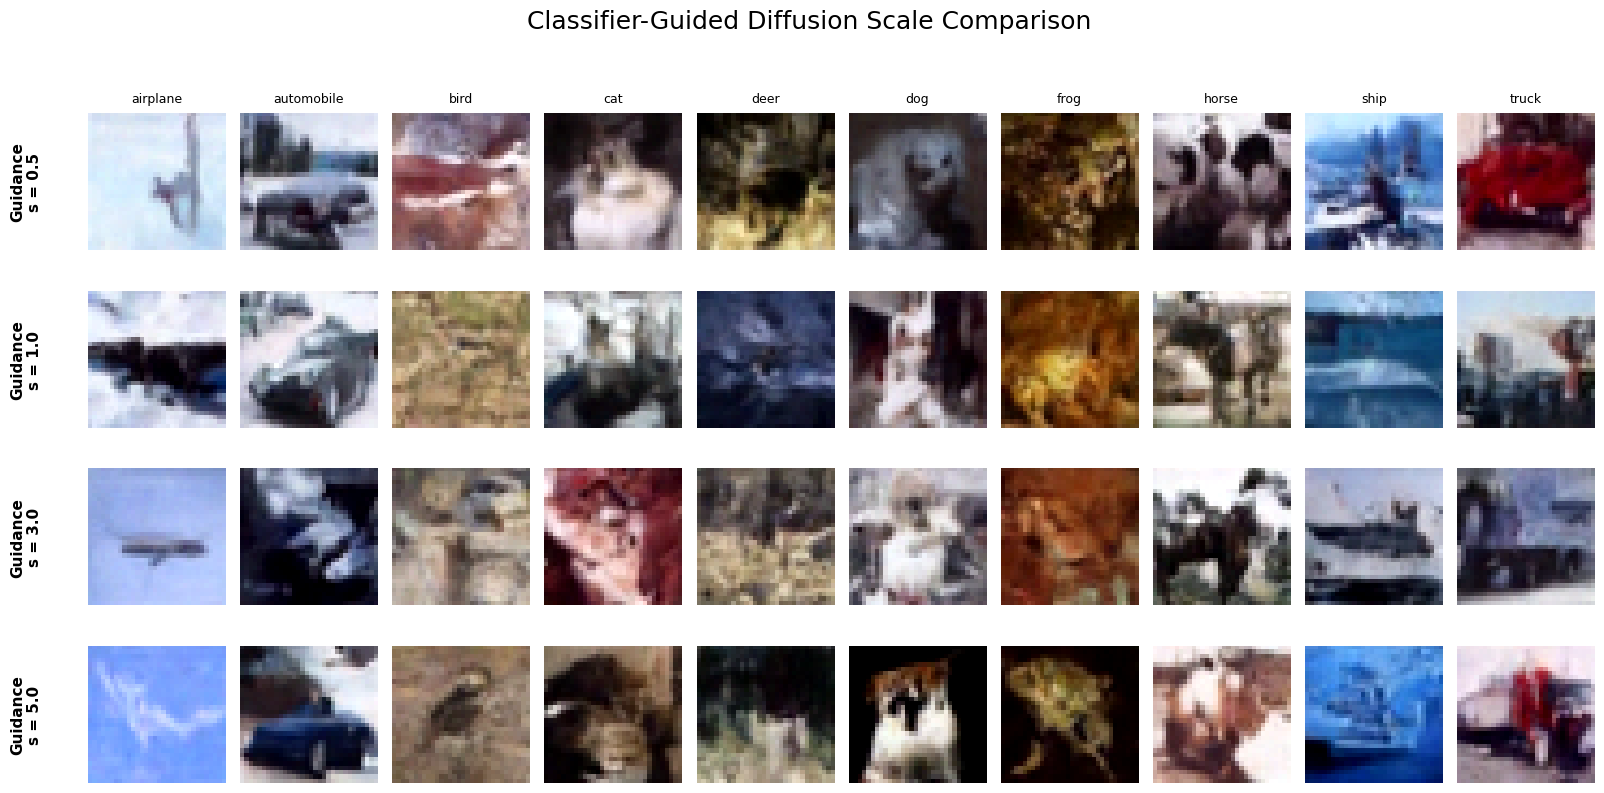

In [ ]:
def visualize_classifier_guidance_comparison(
    model,
    classifier,
    schedule,
    target_classes,
    cfg,
    device,
    guidance_scales=[0.5, 1.0, 3.0, 5.0],
    save_path=None
):

    ema.apply_shadow()

    rows = len(guidance_scales)
    cols = len(target_classes)

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(cols * 1.6, rows * 2.0)
    )

    # Handle edge case
    if rows == 1:
        axes = axes[None, :]

    # Fixed seed for fair comparison
    torch.manual_seed(42)

    for row, s in enumerate(guidance_scales):

        samples = sample_classifier_guided(
            model,
            classifier,
            schedule,
            len(target_classes),
            target_classes,
            cfg,
            device,
            s=s
        )

        # Denormalize
        samples = (samples * 0.5 + 0.5).clamp(0, 1)

        for col in range(cols):

            img = samples[col].permute(1,2,0).cpu().numpy()

            axes[row, col].imshow(img)
            axes[row, col].axis('off')

            # Column titles
            if row == 0:
                axes[row, col].set_title(
                    cfg.class_names[target_classes[col]],
                    fontsize=9,
                    pad=8
                )

        # Guidance scale labels
        axes[row, 0].text(
            -0.45,
            0.5,
            f'Guidance\ns = {s}',
            transform=axes[row, 0].transAxes,
            fontsize=11,
            va='center',
            ha='center',
            rotation=90,
            fontweight='bold'
        )

    plt.suptitle(
        'Classifier-Guided Diffusion Scale Comparison',
        fontsize=18,
        y=1.02
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches='tight'
        )

    plt.show()

    ema.restore()

#Implementation

target_classes = torch.arange(10, device=device)

visualize_classifier_guidance_comparison(
    model,
    classifier,
    schedule,
    target_classes,
    cfg,
    device,
    guidance_scales=[0.5, 1.0, 3.0, 5.0],
    save_path='classifier_guidance_comparison.png'
)

## 15. Side-by-Side Comparison

Comparing all three methods for a single target class (cat considered here).

Generating 8 images of class 'cat' with different guidance methods...


DDPM:   0%|          | 0/1000 [00:00<?, ?it/s]

CFG (w=3.0):   0%|          | 0/1000 [00:00<?, ?it/s]

CG (s=1.0):   0%|          | 0/1000 [00:00<?, ?it/s]

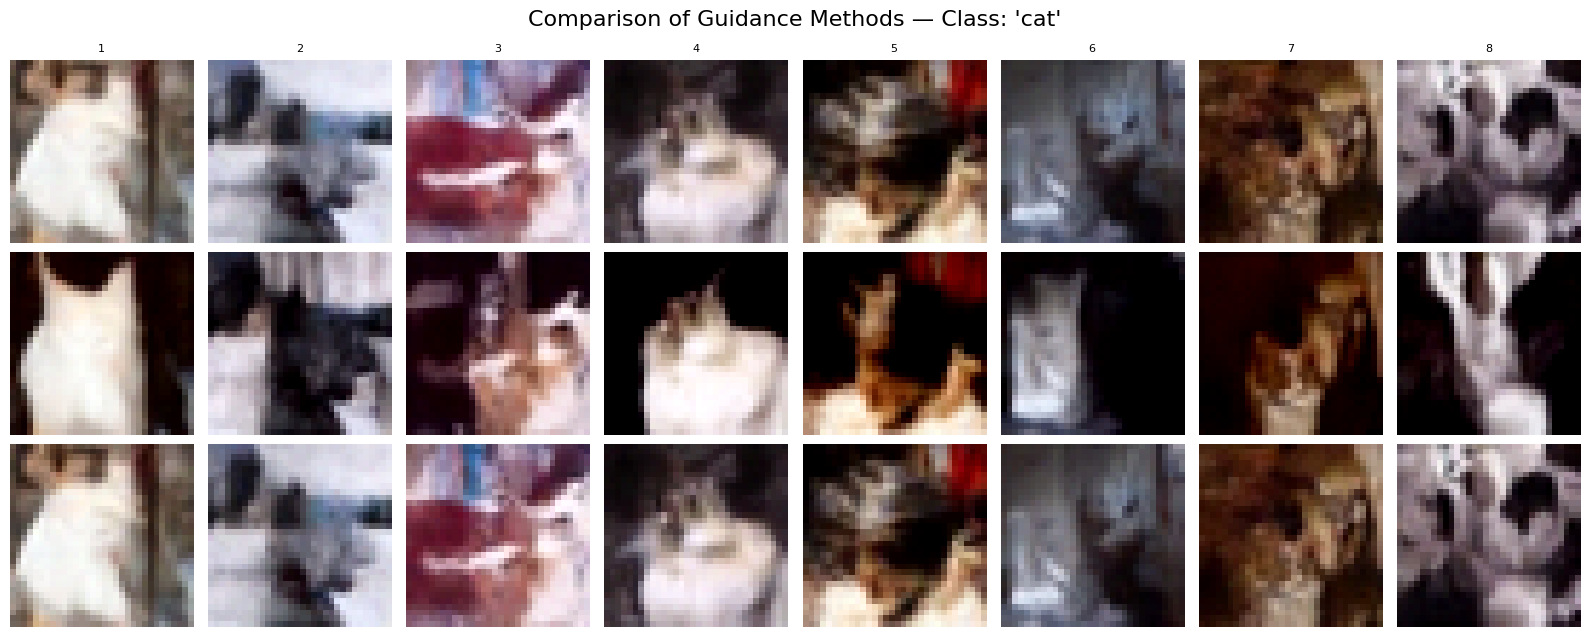

In [ ]:
ema.apply_shadow()

# ----------------------------
# Settings
# ----------------------------
n = 8

target_class = 3  # cat

labels = torch.full(
    (n,),
    target_class,
    device=device,
    dtype=torch.long
)

print(
    f"Generating {n} images of class "
    f"'{cfg.class_names[target_class]}' "
    f"with different guidance methods..."
)

# ----------------------------
# Fixed random seed
# Ensures fair comparison
# ----------------------------
torch.manual_seed(42)

samples_plain = sample_ddpm(
    model,
    schedule,
    n,
    labels,
    cfg,
    device
)

torch.manual_seed(42)

samples_cfg = sample_classifier_free(
    model,
    schedule,
    n,
    labels,
    cfg,
    device,
    w=cfg.cfg_scale
)

torch.manual_seed(42)

samples_cg = sample_classifier_guided(
    model,
    classifier,
    schedule,
    n,
    labels,
    cfg,
    device,
    s=cfg.cg_scale
)

# ----------------------------
# Visualization
# ----------------------------
fig, axes = plt.subplots(
    3,
    n,
    figsize=(n * 2, 6.5)
)

titles = [
    'Baseline Conditional DDPM',
    f'Classifier-Free Guidance (w={cfg.cfg_scale})',
    f'Classifier Guidance (s={cfg.cg_scale})'
]

all_samples = [
    samples_plain,
    samples_cfg,
    samples_cg
]

for row, (samples, title) in enumerate(zip(all_samples, titles)):

    for col in range(n):

        img = (
            samples[col] * 0.5 + 0.5
        ).clamp(0, 1)

        img = img.permute(1, 2, 0).cpu().numpy()

        axes[row, col].imshow(img)
        axes[row, col].axis('off')

        # Optional sample numbering
        if row == 0:
            axes[row, col].set_title(
                f'{col + 1}',
                fontsize=8
            )

    # Row labels
    axes[row, 0].set_ylabel(
        title,
        fontsize=10,
        rotation=90,
        labelpad=70,
        fontweight='bold'
    )

plt.suptitle(
    f"Comparison of Guidance Methods — "
    f"Class: '{cfg.class_names[target_class]}'",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "guidance_method_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

ema.restore()

## 16. Grid of All Classes — All Methods

DDPM:   0%|          | 0/1000 [00:00<?, ?it/s]

CFG (w=3.0):   0%|          | 0/1000 [00:00<?, ?it/s]

CG (s=1.0):   0%|          | 0/1000 [00:00<?, ?it/s]

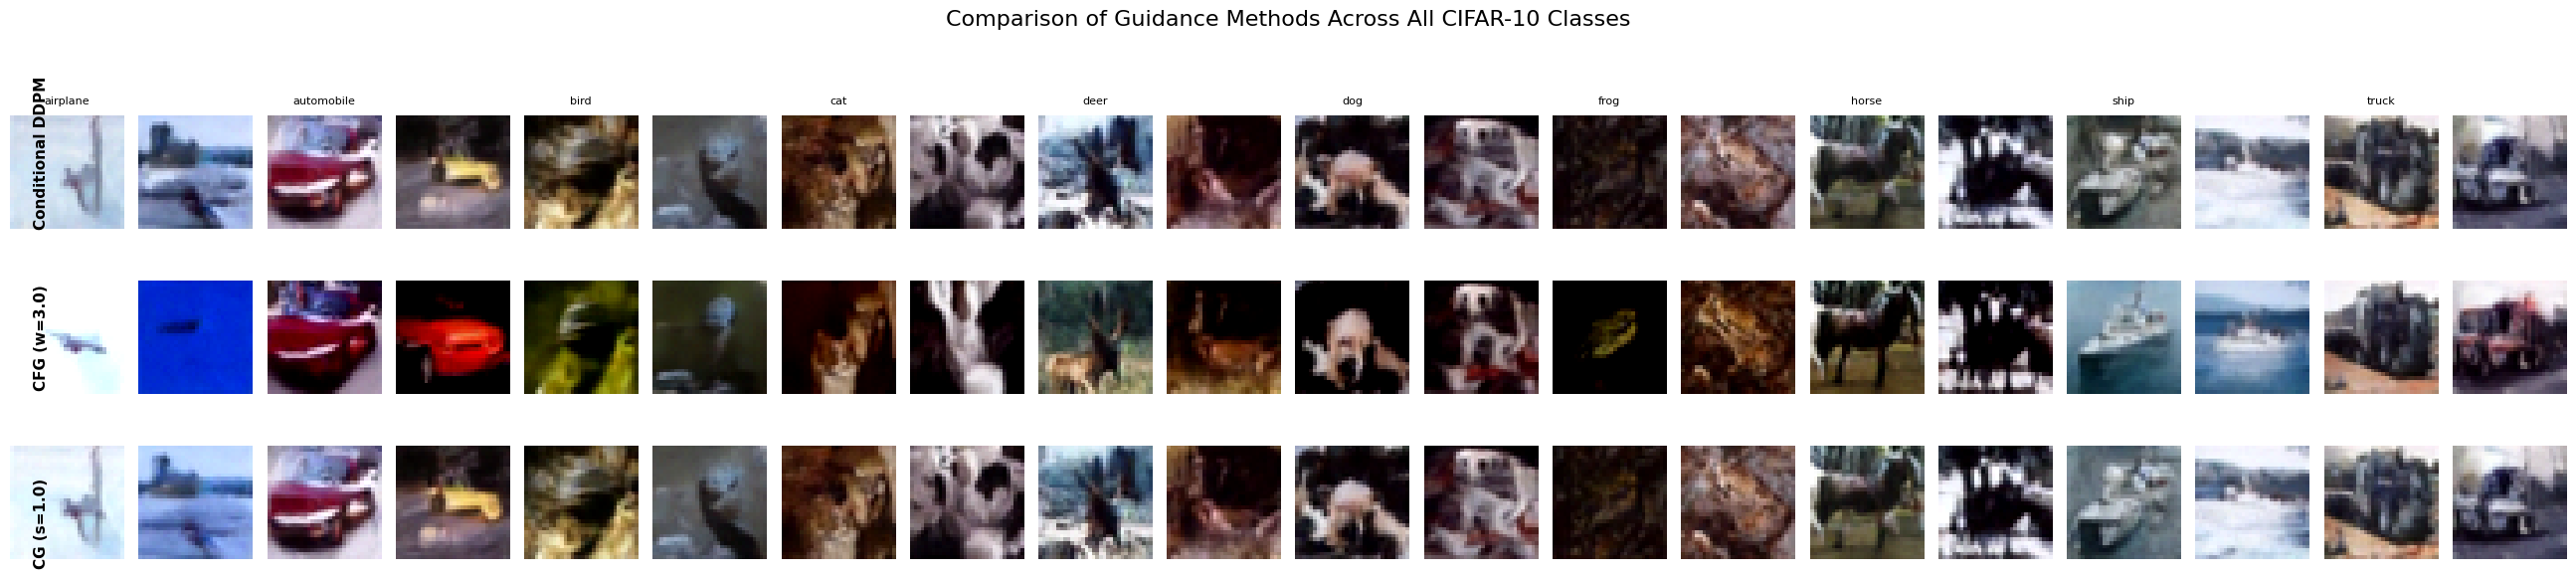

In [ ]:
ema.apply_shadow()

n_per_class = 2

methods = {
    'Conditional DDPM': lambda labels: sample_ddpm(
        model,
        schedule,
        len(labels),
        labels,
        cfg,
        device
    ),

    f'CFG (w={cfg.cfg_scale})': lambda labels: sample_classifier_free(
        model,
        schedule,
        len(labels),
        labels,
        cfg,
        device,
        w=cfg.cfg_scale
    ),

    f'CG (s={cfg.cg_scale})': lambda labels: sample_classifier_guided(
        model,
        classifier,
        schedule,
        len(labels),
        labels,
        cfg,
        device,
        s=cfg.cg_scale
    ),
}

# ----------------------------
# Figure
# ----------------------------
fig, axes = plt.subplots(
    len(methods),
    cfg.num_classes * n_per_class,
    figsize=(
        cfg.num_classes * n_per_class * 1.3,
        len(methods) * 2
    )
)

# Handle single-row edge case
if len(methods) == 1:
    axes = axes[None, :]

# ----------------------------
# Generate & plot
# ----------------------------
for row, (method_name, sample_fn) in enumerate(methods.items()):

    all_labels = torch.arange(
        cfg.num_classes,
        device=device
    ).repeat_interleave(n_per_class)

    # Fixed seed for fair comparison
    torch.manual_seed(42)

    samples = sample_fn(all_labels)

    for col in range(len(all_labels)):

        img = (
            samples[col] * 0.5 + 0.5
        ).clamp(0,1)

        img = img.permute(1,2,0).cpu().numpy()

        axes[row, col].imshow(img)
        axes[row, col].axis('off')

        # Column titles
        if row == 0:

            class_idx = col // n_per_class

            if col % n_per_class == 0:

                axes[row, col].set_title(
                    cfg.class_names[class_idx],
                    fontsize=8,
                    pad=8
                )

    # Better visible row labels
    fig.text(
        0.015,
        0.78 - row * 0.31,
        method_name,
        fontsize=11,
        fontweight='bold',
        rotation=90,
        va='center'
    )

# ----------------------------
# Main title
# ----------------------------
plt.suptitle(
    'Comparison of Guidance Methods Across All CIFAR-10 Classes',
    fontsize=16,
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "all_classes_all_methods.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

ema.restore()

## 17. Guidance Scale Sweep Visualization

Showing how increasing guidance scale affects sample quality and diversity.

CFG (w=0.0):   0%|          | 0/1000 [00:00<?, ?it/s]

CFG (w=0.5):   0%|          | 0/1000 [00:00<?, ?it/s]

CFG (w=1.0):   0%|          | 0/1000 [00:00<?, ?it/s]

CFG (w=2.0):   0%|          | 0/1000 [00:00<?, ?it/s]

CFG (w=3.0):   0%|          | 0/1000 [00:00<?, ?it/s]

...

CG (s=1.0):   0%|          | 0/1000 [00:00<?, ?it/s]

CG (s=2.0):   0%|          | 0/1000 [00:00<?, ?it/s]

CG (s=3.0):   0%|          | 0/1000 [00:00<?, ?it/s]

CG (s=5.0):   0%|          | 0/1000 [00:00<?, ?it/s]

CG (s=7.0):   0%|          | 0/1000 [00:00<?, ?it/s]

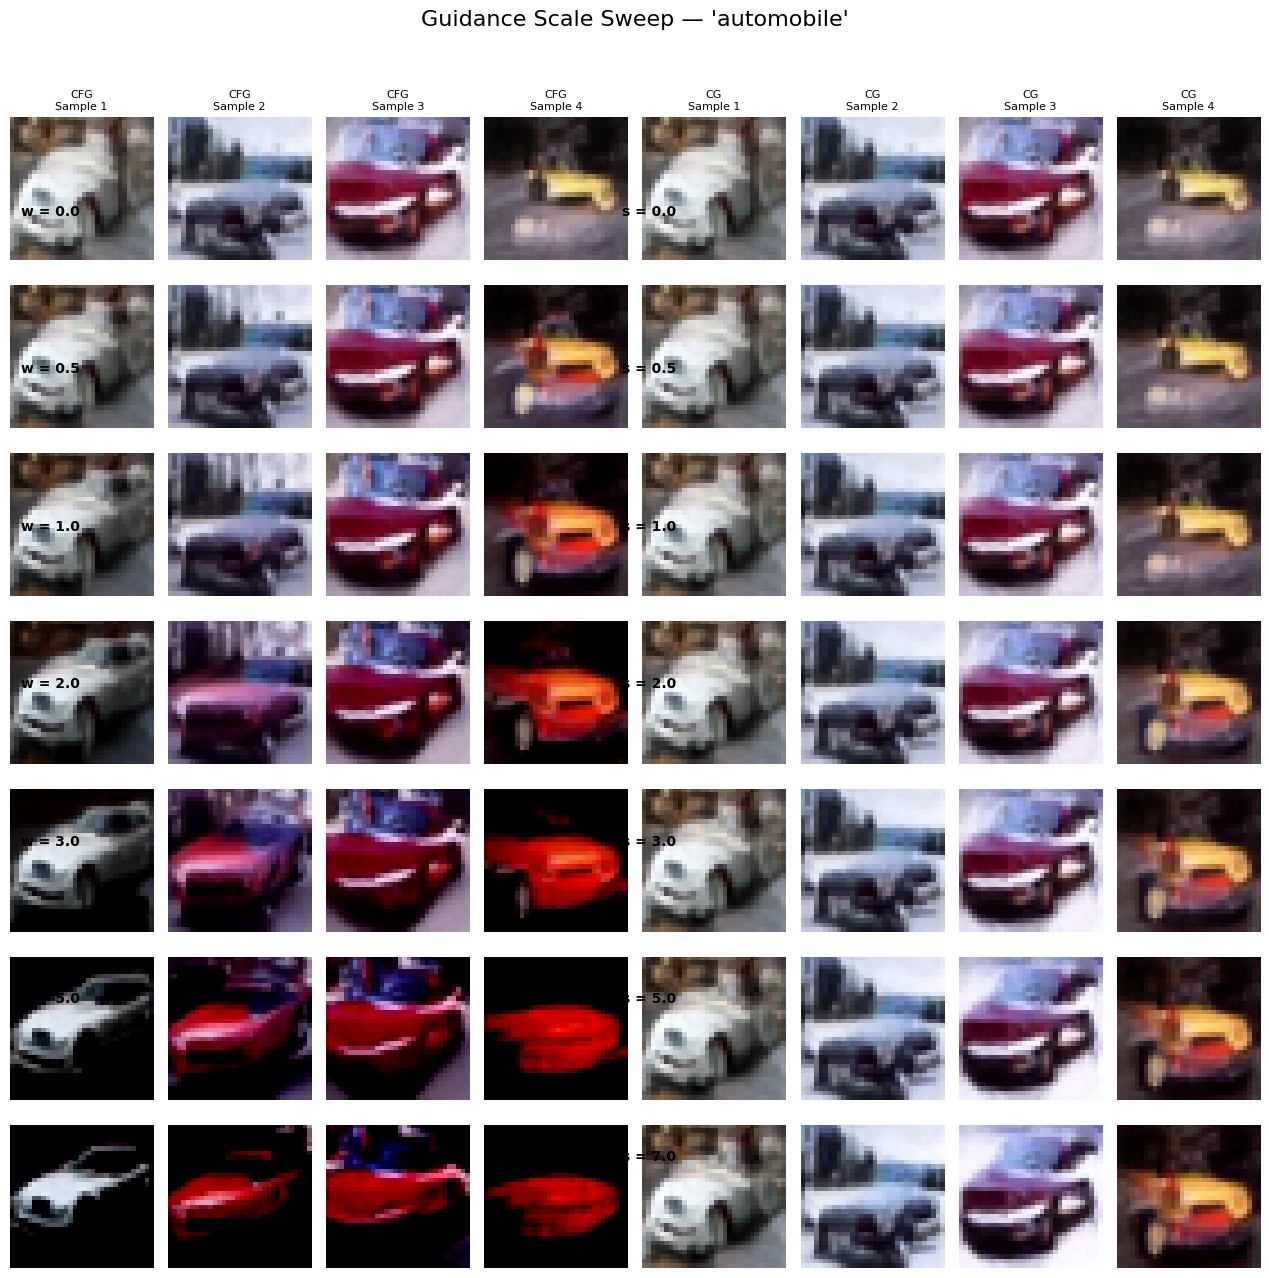

In [ ]:
ema.apply_shadow()

target_class = 1  # automobile
n = 4

labels = torch.full(
    (n,),
    target_class,
    device=device,
    dtype=torch.long
)

cfg_scales = [0.0, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0]
cg_scales  = [0.0, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0]

# ----------------------------
# Create combined figure
# ----------------------------
fig, axes = plt.subplots(
    len(cfg_scales),
    n * 2,
    figsize=(n * 3.2, len(cfg_scales) * 1.8)
)

# ----------------------------
# CFG Sweep
# ----------------------------
for row, w in enumerate(cfg_scales):

    torch.manual_seed(42)

    samples_cfg = sample_classifier_free(
        model,
        schedule,
        n,
        labels,
        cfg,
        device,
        w=w
    )

    for col in range(n):

        img = (
            samples_cfg[col] * 0.5 + 0.5
        ).clamp(0,1)

        img = img.permute(1,2,0).cpu().numpy()

        axes[row, col].imshow(img)
        axes[row, col].axis('off')

        # Column titles
        if row == 0:
            axes[row, col].set_title(
                f'CFG\nSample {col+1}',
                fontsize=8
            )

    # Better row labels
    fig.text(
        0.02,
        0.86 - row * 0.125,
        f'w = {w}',
        fontsize=10,
        fontweight='bold',
        va='center'
    )

# ----------------------------
# CG Sweep
# ----------------------------
for row, s in enumerate(cg_scales):

    torch.manual_seed(42)

    samples_cg = sample_classifier_guided(
        model,
        classifier,
        schedule,
        n,
        labels,
        cfg,
        device,
        s=s
    )

    for col in range(n):

        img = (
            samples_cg[col] * 0.5 + 0.5
        ).clamp(0,1)

        img = img.permute(1,2,0).cpu().numpy()

        axes[row, col + n].imshow(img)
        axes[row, col + n].axis('off')

        if row == 0:
            axes[row, col + n].set_title(
                f'CG\nSample {col+1}',
                fontsize=8
            )

    fig.text(
        0.49,
        0.86 - row * 0.125,
        f's = {s}',
        fontsize=10,
        fontweight='bold',
        va='center'
    )

# ----------------------------
# Main title
# ----------------------------
plt.suptitle(
    f"Guidance Scale Sweep — '{cfg.class_names[target_class]}'",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "guidance_scale_sweep.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

ema.restore()

## 18. Denoising Process Visualization

Visualizing intermediate steps of the reverse diffusion process. Below we show the reverse diffusion for classifier free guidance.

Denoising:   0%|          | 0/1000 [00:00<?, ?it/s]

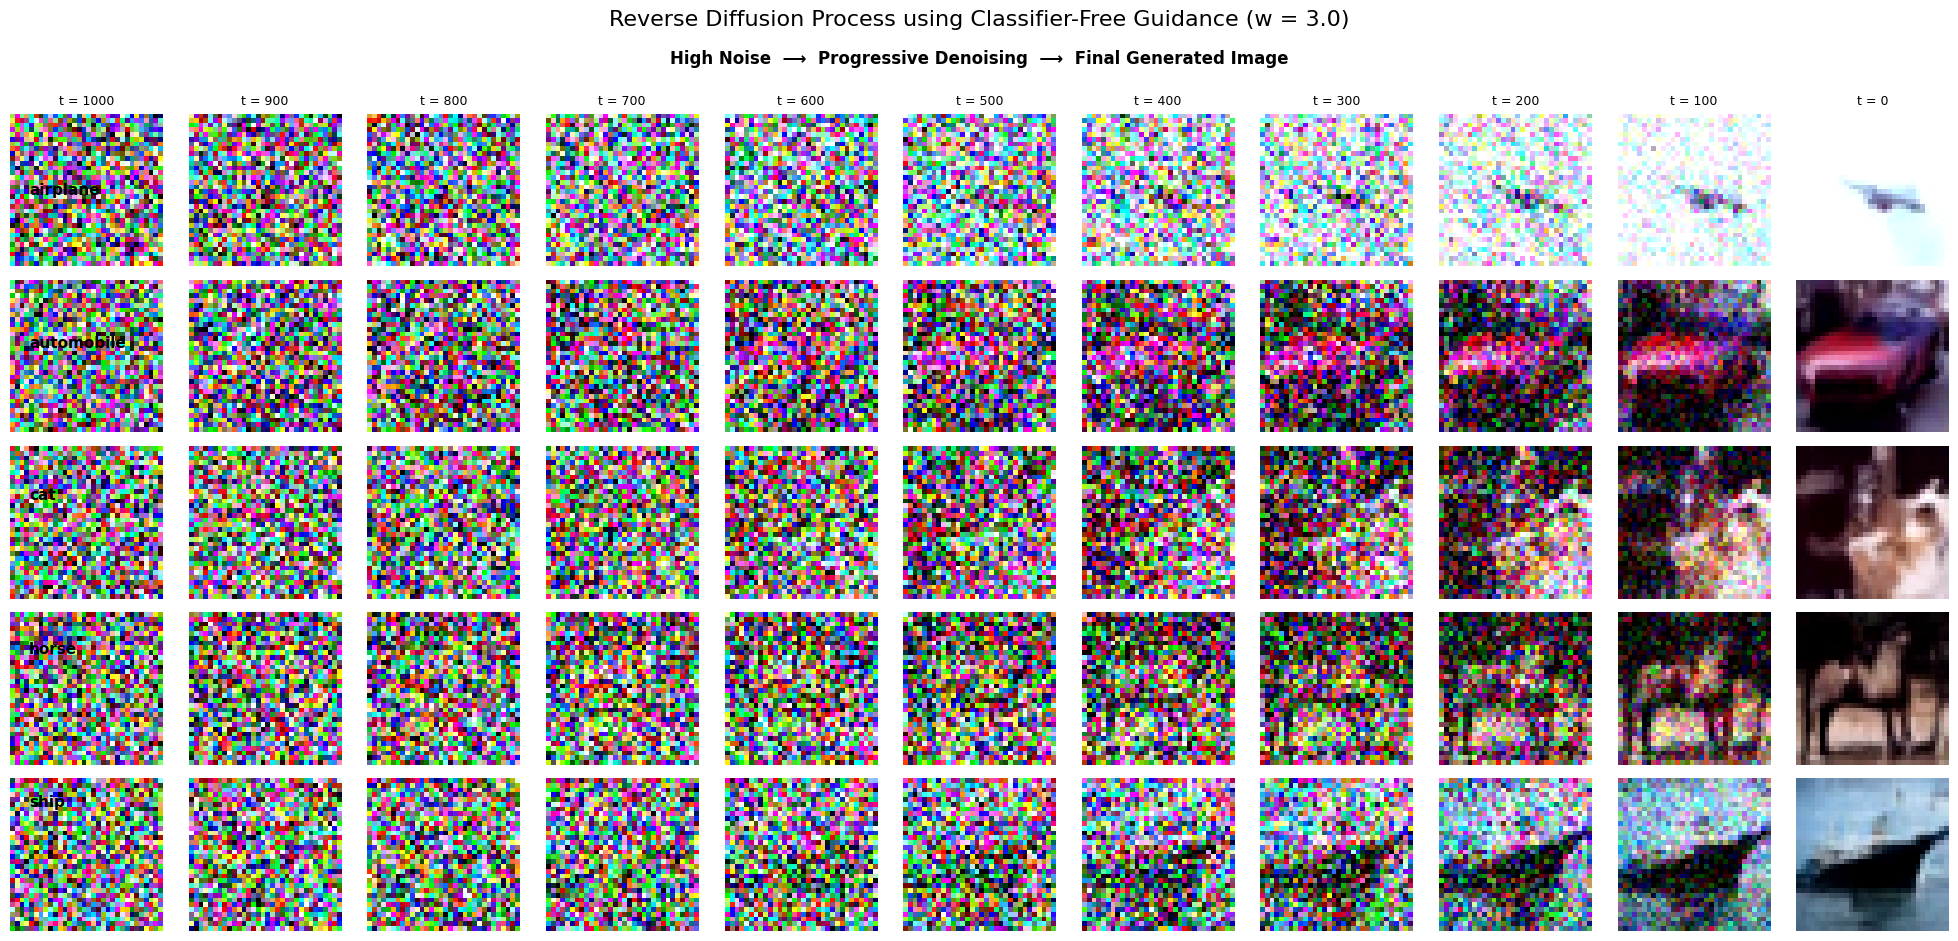

In [ ]:
@torch.no_grad()
def sample_with_intermediates(
    model,
    schedule,
    labels,
    cfg,
    device,
    w=3.0,
    save_every=100
):
    """
    Sample using Classifier-Free Guidance (CFG)
    and save intermediate denoising steps.
    """

    model.eval()

    n = len(labels)

    # Start from Gaussian noise
    x = torch.randn(
        n,
        cfg.channels,
        cfg.image_size,
        cfg.image_size,
        device=device
    )

    null_labels = torch.full_like(
        labels,
        cfg.num_classes
    )

    intermediates = [(cfg.timesteps, x.clone())]

    # Reverse diffusion process
    for t in tqdm(
        reversed(range(cfg.timesteps)),
        total=cfg.timesteps,
        desc="Denoising"
    ):

        t_batch = torch.full(
            (n,),
            t,
            device=device,
            dtype=torch.long
        )

        # Conditional prediction
        eps_cond = model(
            x,
            t_batch,
            labels
        )

        # Unconditional prediction
        eps_uncond = model(
            x,
            t_batch,
            null_labels
        )

        # CFG combination
        predicted_noise = (
            (1 + w) * eps_cond
            - w * eps_uncond
        )

        alpha = schedule.alphas[t]
        alpha_bar = schedule.alphas_cumprod[t]
        beta = schedule.betas[t]

        # DDPM reverse step
        mean = (
            1 / torch.sqrt(alpha)
        ) * (
            x
            - (
                beta
                / torch.sqrt(1 - alpha_bar)
            ) * predicted_noise
        )

        if t > 0:
            x = mean + torch.sqrt(beta) * torch.randn_like(x)
        else:
            x = mean

        # Save intermediates
        if t % save_every == 0 or t == 0:
            intermediates.append((t, x.clone()))

    model.train()

    return intermediates


# ============================================================
# Reverse Diffusion Visualization
# ============================================================

ema.apply_shadow()

# Reproducibility
torch.manual_seed(42)

# Selected classes
labels = torch.tensor(
    [0, 1, 3, 7, 8],  # airplane, automobile, cat, horse, ship
    device=device
)

# Generate intermediates
intermediates = sample_with_intermediates(
    model,
    schedule,
    labels,
    cfg,
    device,
    w=3.0,
    save_every=100
)

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------
fig, axes = plt.subplots(
    len(labels),
    len(intermediates),
    figsize=(
        len(intermediates) * 1.8,
        len(labels) * 1.8
    )
)

# Handle edge case
if len(labels) == 1:
    axes = axes[None, :]

# Plot intermediate denoising steps
for col, (t, imgs) in enumerate(intermediates):

    for row in range(len(labels)):

        img = (
            imgs[row] * 0.5 + 0.5
        ).clamp(0, 1)

        img = img.permute(1, 2, 0).cpu().numpy()

        axes[row, col].imshow(img)
        axes[row, col].axis('off')

    # Timestep labels
    axes[0, col].set_title(
        f't = {t}',
        fontsize=9
    )

# Better visible class labels
for row in range(len(labels)):

    fig.text(
        0.02,
        0.84 - row * 0.17,
        cfg.class_names[labels[row]],
        fontsize=11,
        fontweight='bold',
        va='center'
    )

# Direction annotation
fig.text(
    0.5,
    0.98,
    'High Noise  ⟶  Progressive Denoising  ⟶  Final Generated Image',
    ha='center',
    fontsize=12,
    fontweight='bold'
)

# Main title
plt.suptitle(
    'Reverse Diffusion Process using Classifier-Free Guidance (w = 3.0)',
    fontsize=16,
    y=1.04
)

plt.tight_layout()

# Save for PPT
plt.savefig(
    "reverse_diffusion_process.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

ema.restore()

## 19. FID Score Computation

Computing FID (Frechet Inception Distance) to quantitatively compare sample quality. This requires generating many samples.We are generating 1000 samples.

In [ ]:
!pip install -q pytorch-fid

In [ ]:
from torchvision.utils import save_image
from pytorch_fid import fid_score


def compute_fid(model, schedule, sample_fn, cfg, device,
                n_samples=1000, batch_size=50, method_name="method", **kwargs):
    """Generate samples and compute FID against CIFAR-10 training set."""

    real_dir = "fid_real"
    fake_dir = f"fid_fake_{method_name}"
    os.makedirs(real_dir, exist_ok=True)
    os.makedirs(fake_dir, exist_ok=True)

    # Save real images
    if len(os.listdir(real_dir)) < n_samples:
        print(f"Saving {n_samples} real images...")
        real_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        count = 0
        for imgs, _ in real_loader:
            for img in imgs:
                if count >= n_samples:
                    break
                save_image(img * 0.5 + 0.5, f"{real_dir}/{count:05d}.png")
                count += 1
            if count >= n_samples:
                break

    # Generate and save fake images
    print(f"Generating {n_samples} samples with {method_name}...")
    count = 0
    while count < n_samples:
        bs = min(batch_size, n_samples - count)
        labels = torch.randint(0, cfg.num_classes, (bs,), device=device)
        samples = sample_fn(model, schedule, bs, labels, cfg, device, **kwargs)
        for img in samples:
            save_image(img * 0.5 + 0.5, f"{fake_dir}/{count:05d}.png")
            count += 1

    fid = fid_score.calculate_fid_given_paths(
        [real_dir, fake_dir], batch_size=50, device=device, dims=2048
    )
    print(f"FID ({method_name}): {fid:.2f}")
    return fid

In [ ]:
# compute FID
ema.apply_shadow()

fid_ddpm = compute_fid(model, schedule, sample_ddpm, cfg, device,
                       n_samples=1000, method_name="ddpm")

fid_cfg = compute_fid(model, schedule, sample_classifier_free, cfg, device,
                      n_samples=1000, method_name="cfg", w=cfg.cfg_scale)

# Commenting the below code as it is erroraneous. Correct implementation is there at the next cell.
# fid_cg = compute_fid(model, schedule,
#                      lambda m, s, n, l, c, d, **kw: sample_classifier_guided(m, classifier, s, n, l, c, d, **kw),
#                      cfg, device, n_samples=1000, method_name="cg", s=cfg.cg_scale)

print(f"\nFID Summary:")
print(f"  DDPM (no guidance):      {fid_ddpm:.2f}")
print(f"  Classifier-Free (w={cfg.cfg_scale}): {fid_cfg:.2f}")
print(f"  Classifier-Guided (s={cfg.cg_scale}): {fid_cg:.2f}")

ema.restore()

Saving 1000 real images...
Generating 1000 samples with ddpm...


DDPM:   0%|          | 0/1000 [00:00<?, ?it/s]

DDPM:   0%|          | 0/1000 [00:00<?, ?it/s]

DDPM:   0%|          | 0/1000 [00:00<?, ?it/s]

DDPM:   0%|          | 0/1000 [00:00<?, ?it/s]

...

CFG (w=3.0):   0%|          | 0/1000 [00:00<?, ?it/s]

CFG (w=3.0):   0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 32.36it/s]


FID (cfg): 88.17
Generating 1000 samples with cg...


TypeError: <lambda>() got multiple values for argument 's'

In [ ]:
#corrected implementation
fid_cg = compute_fid(model, schedule,
                     lambda m, sch, n, l, c, d, **kw: sample_classifier_guided(m, classifier, sch, n, l, c, d, **kw),
                     cfg, device, n_samples=1000, method_name="cg", s=cfg.cg_scale)
print(f"\nFID Summary:")
print(f"  DDPM (no guidance):      {fid_ddpm:.2f}")
print(f"  Classifier-Free (w={cfg.cfg_scale}): {fid_cfg:.2f}")
print(f"  Classifier-Guided (s={cfg.cg_scale}): {fid_cg:.2f}")
ema.restore()

Generating 1000 samples with cg...


CG (s=1.0):   0%|          | 0/1000 [00:00<?, ?it/s]

CG (s=1.0):   0%|          | 0/1000 [00:00<?, ?it/s]

CG (s=1.0):   0%|          | 0/1000 [00:00<?, ?it/s]

CG (s=1.0):   0%|          | 0/1000 [00:00<?, ?it/s]

...

CG (s=1.0):   0%|          | 0/1000 [00:00<?, ?it/s]

CG (s=1.0):   0%|          | 0/1000 [00:00<?, ?it/s]

CG (s=1.0):   0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:00<00:00, 32.06it/s]


FID (cg): 101.23

FID Summary:
  DDPM (no guidance):      111.25
  Classifier-Free (w=3.0): 88.17
  Classifier-Guided (s=1.0): 101.23


## 20. Saving Models

In [ ]:
# Save checkpoints
ema.apply_shadow()
torch.save({
    'model_state_dict': model.state_dict(),
    'classifier_state_dict': classifier.state_dict(),
    'config': vars(cfg),
    'diff_losses': diff_losses,
    'cls_losses': cls_losses,
    'cls_accs': cls_accs,
}, 'diffusion_cifar10_checkpoint.pt')
ema.restore()

print("Checkpoint saved to diffusion_cifar10_checkpoint.pt")


Checkpoint saved to diffusion_cifar10_checkpoint.pt


## 21. Summary & Analysis

### Method Comparison

| Aspect | Classifier-Free Guidance | Classifier-Guided |
|--------|--------------------------|--------------------|
| **Extra model needed** | No (single U-Net) | Yes (separate classifier) |
| **Training** | Label dropout during U-Net training | Trained classifier on noisy images |
| **Sampling cost** | ~2x forward passes (cond + uncond) | 1 forward + 1 backward (gradient) |
| **Guidance mechanism** | Interpolation in noise space | Gradient of log p(y \| x_t) |
| **Flexibility** | Must retrain if conditioning changes | Can swap classifiers without retraining diffusion model |
| **Key paper** | Ho & Salimans, 2022 | Dhariwal & Nichol, 2021 |

### Key Observations

1. **Guidance scale trade-off:** Higher guidance scale improves class fidelity but reduces diversity (mode collapse at extreme values)
2. **Classifier-free** is simpler and more widely adopted in modern systems
3. **Classifier-guided** offers modularity — the diffusion model and classifier are independent
4. Training longer (100+ epochs) could significantly improve sample quality

## References

1. Ho, J., Jain, A., & Abbeel, P. (2020). *Denoising Diffusion Probabilistic Models.* NeurIPS.
2. Dhariwal, P., & Nichol, A. (2021). *Diffusion Models Beat GANs on Image Synthesis.* NeurIPS.
3. Ho, J., & Salimans, T. (2022). *Classifier-Free Diffusion Guidance.* NeurIPS Workshop.